# PSO Optic Ray Trace
## Alexandra Higley

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker
from matplotlib import cm
import sys
import pdb
from copy import deepcopy
from tqdm import tqdm
import astropy.units as u
import mpl_scatter_density

import seaborn as sns
plt.style.use('seaborn')

/var/folders/d7/mj7t5gvn7kxcpnv91gn5rxs5myk4z8/T/ipykernel_92859/2184438354.py:13: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


In [2]:
sys.path.append('/Users/anh5866/Desktop/Coding') #change path as needed
import PyXFocus.sources as sources
import PyXFocus.transformations as trans
import PyXFocus.surfaces as surfaces
import PyXFocus.analyses as analyses
import PyXFocus.conicsolve as conic

import OGRE.ogre_routines_alexplay as ogre

soxs : [WARNING  ] 2025-12-15 15:42:18,326 Setting 'soxs_data_dir' to /Users/anh5866/Library/Caches/soxs for this session. Please update your configuration if you want it somewhere else.


In [3]:
# Defining PSO optic parameters.
z0 = 3500. * u.mm  # Focal length.

r_int = np.array([185.836, 191.305]) * u.mm #Radius at intersection node
# there are only two because this is a double shell optic 


mirror_length = 100 * u.mm  # Axial length of primary / secondary mirror (how long are they)
mirror_sep = 5 * u.mm  # Separation between primary and secondary mirrors. 
#For JET-X, this is zero because the primary and secondary mirrors are continuous 

#For this raytrace, we are pretending we are in PANTER

# PANTER Parameters
L = (123000. + 12000) * u.mm  # Approximate vaccuum chanber length 
L -= 4000. * u.mm  # Accounts for focal length of optic in the finite conjugate.
#L = 10e12 * u.mm # sometimes I like to pretend the source is infinitley far away and 
#I comment out the two lines above and uncomment this to do that 

#wave = 0.98903  # [nm] Mg-K wavelength.
wave = 0.83401 * u.nm # Al-K wavelength. --> used later on for the diffraction grating ray traces. 
#there will be no grating in this trace.

# I like using astropy units
print(r_int)
print(L)

[185.836 191.305] mm
131000.0 mm


## Optic Simulation 

In [4]:
# Define inner and outer subannulus radii. ie, where on the z-axis is the start of the mirror and the end
z_in = z0 + mirror_sep/2
z_out = z_in + mirror_length

print(z_in)
print(z_out)

# function to determine radius at these 
r_in = conic.primrad(z_in, r_int[0], z0)
r_out = conic.primrad(z_out, r_int[-1], z0) #-1 is the last value in array 

print(r_in)
print(r_out)

3502.5 mm
3602.5 mm
185.86915285426616 mm
192.69923985012488 mm


In [5]:
dphi = 30 * u.deg # subapperature the shell. If you want the full anulus, change to 360. 
#the PSO we tested at PANTER was only a subannulus 

#not sure if this is entirely correct -- by math it seems like it is more around 27 degrees maybe? 
#Idk how much of an impact this change would have, but ig I'll find out 

In [6]:
# Define subannulus of rays.
rays = sources.subannulus(r_in.to('mm').value, r_out.to('mm').value,
                          dphi.to('rad').value, 100000)

In [7]:
# Rotate so that dispersion direction is in the x-dimension.
trans.transform(rays, 0, 0, 0, 0, 0, -np.pi/2)

rays

[array([0., 0., 0., ..., 0., 0., 0.]),
 array([-13.9258477 ,  15.09561118,  28.66520563, ..., -37.13165988,
        -32.16754519,  45.827487  ]),
 array([186.89641423, 188.53353637, 186.32959653, ..., 183.87052952,
        188.27915877, 183.777755  ]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([1., 1., 1., ..., 1., 1., 1.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.])]

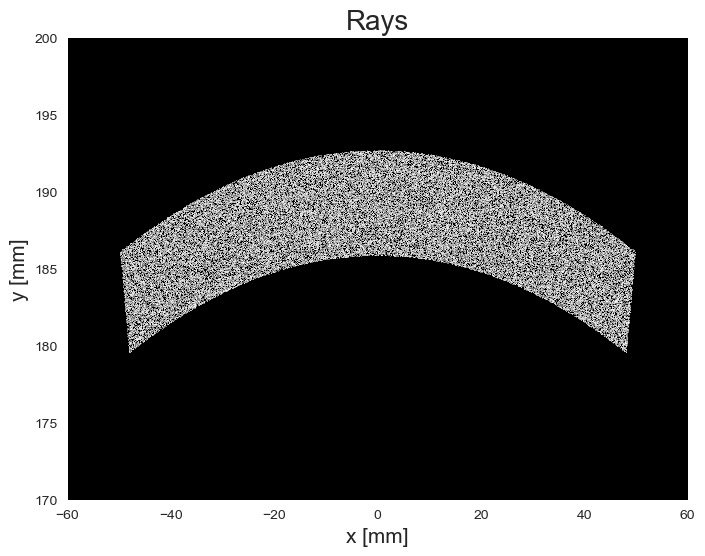

In [8]:
with sns.axes_style("ticks"):
#with sns.axes_style("whitegrid"):
    
    #matplotlib.rc('text',usetex=True)
    #matplotlib.rc('font',size=15)
    fig1,ax1 = plt.subplots(figsize=(8,6))

    ax1.set_xlabel('x [mm]', fontsize=15)
    ax1.set_ylabel('y [mm]', fontsize=15)
    
    ax1.set_xlim(-60,60)
    ax1.set_ylim(170,200)
    
    color_map = plt.get_cmap('plasma')
    ax1.set_facecolor('black')

    ax1.scatter(rays[1], rays[2], color="white", alpha=0.6, marker='.',  s=0.5)

    ax1.tick_params(axis='both',which='minor',direction='in')
    ax1.tick_params(top=True,right=True)
    ax1.tick_params(which='minor',top=True,right=True)
    
    #cbar = plt.colorbar(rays)
    #cbar.set_label('Ec', fontsize=15)

    ax1.set_title("Rays", fontsize=20)
    #ax1.grid()

/Users/anh5866/anaconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/Users/anh5866/anaconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


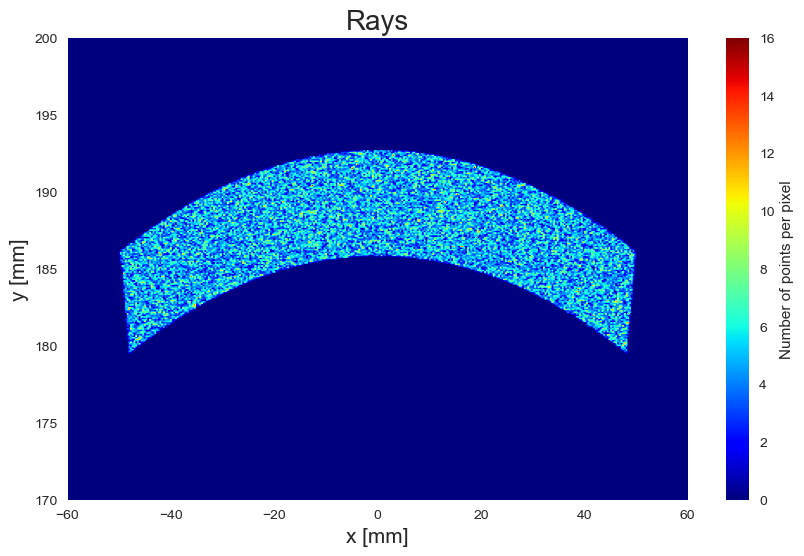

In [9]:
sns.set_style("ticks")
fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(1, 1, 1, projection='scatter_density')

#color_map = plt.get_cmap('plasma')
color_map = plt.get_cmap('jet')

density = ax1.scatter_density(rays[1], rays[2], cmap = color_map)

ax1.set_xlim(-60,60)
ax1.set_ylim(170,200)

ax1.set_xlabel('x [mm]', fontsize=15)
ax1.set_ylabel('y [mm]', fontsize=15)

ax1.set_title("Rays", fontsize=20)

ax1.tick_params(axis='both',which='minor',direction='in')
ax1.tick_params(top=True,right=True)
ax1.tick_params(which='minor',top=True,right=True)

fig.colorbar(density, label='Number of points per pixel')

In [10]:
# Find centroid of rays and move rays down to center of beamline.
cen_optic = analyses.centroid(rays)
trans.transform(rays, 0, cen_optic[1], 0, 0, 0, 0)

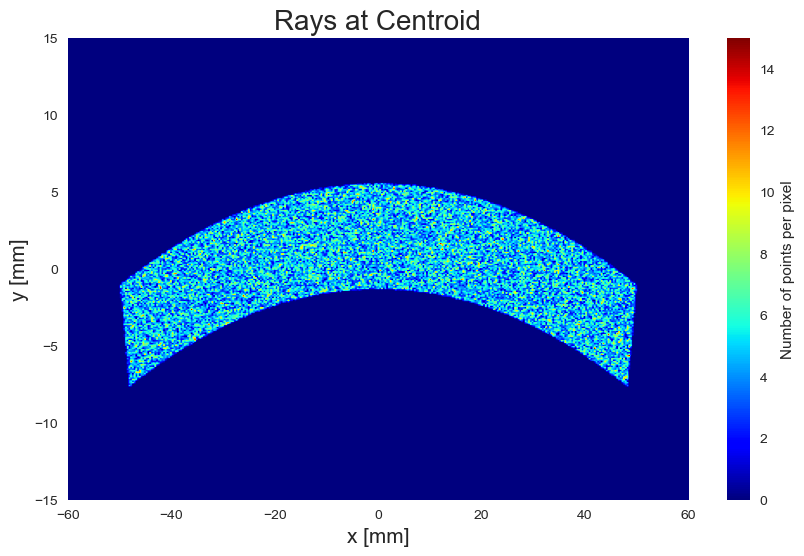

In [11]:
sns.set_style("ticks")
fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(1, 1, 1, projection='scatter_density')

#color_map = plt.get_cmap('plasma')
color_map = plt.get_cmap('jet')

density = ax1.scatter_density(rays[1], rays[2], cmap = color_map)

ax1.set_xlim(-60,60)
ax1.set_ylim(-15,15)

ax1.set_xlabel('x [mm]', fontsize=15)
ax1.set_ylabel('y [mm]', fontsize=15)

ax1.set_title("Rays at Centroid", fontsize=20)

ax1.tick_params(axis='both',which='minor',direction='in')
ax1.tick_params(top=True,right=True)
ax1.tick_params(which='minor',top=True,right=True)

fig.colorbar(density, label='Number of points per pixel')

In [12]:
# Change ray direction cosines to emanate from source (48 m away). Long cell
# Change ray direction cosines to emanate from source (131 m away). PANTER
hyp = np.sqrt(L.to('mm').value**2 + rays[1]**2 + rays[2]**2)
l = rays[1]/hyp
m = rays[2]/hyp
n = -np.sqrt(1. - l**2 - m**2)
rays = [rays[0], rays[1], rays[2], rays[3],
        l, m, n, rays[7], rays[8], rays[9]] #replace l,m,n with newly defined direction cosines

#this is Ben's trick to geometrically alter the direction cosines of the rays such that they came from a source 
#some distance away. 

In [13]:
# Shift rays back up.
trans.transform(rays, 0, -cen_optic[1], 0, 0, 0, 0)

# Move to intersection node of the optic (where the primary mirror meets the secondary).
#it is at the intersection node we do our first reflection -- that's just how the function was written
trans.transform(rays, 0, 0, -z0.to('mm').value, 0, 0, 0)

rays

[array([0., 0., 0., ..., 0., 0., 0.]),
 array([-13.9258477 ,  15.09561118,  28.66520563, ..., -37.13165988,
        -32.16754519,  45.827487  ]),
 array([186.89641423, 188.53353637, 186.32959653, ..., 183.87052952,
        188.27915877, 183.777755  ]),
 array([3500., 3500., 3500., ..., 3500., 3500., 3500.]),
 array([-0.0001063 ,  0.00011523,  0.00021882, ..., -0.00028345,
        -0.00024555,  0.00034983]),
 array([-2.00743402e-06,  1.04896815e-05, -6.33428651e-06, ...,
        -2.51057895e-05,  8.54786759e-06, -2.58139914e-05]),
 array([-0.99999999, -0.99999999, -0.99999998, ..., -0.99999996,
        -0.99999997, -0.99999994]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.])]

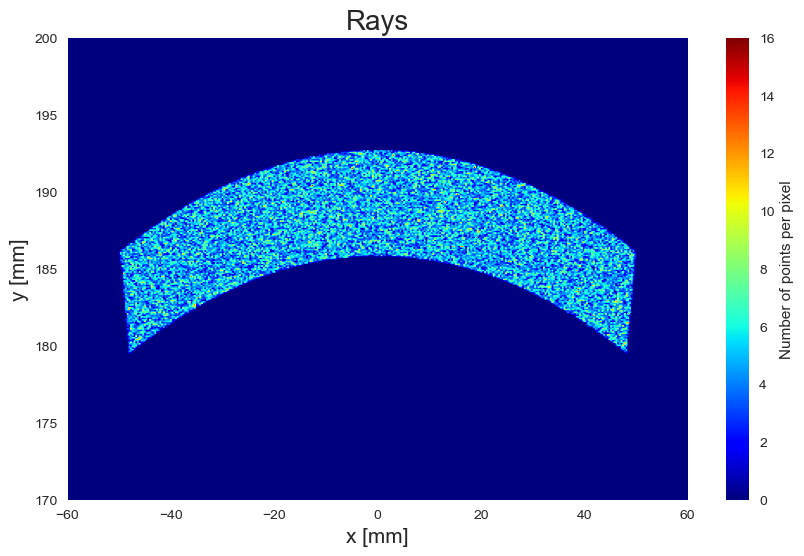

In [14]:
sns.set_style("ticks")
fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(1, 1, 1, projection='scatter_density')

#color_map = plt.get_cmap('plasma')
color_map = plt.get_cmap('jet')

density = ax1.scatter_density(rays[1], rays[2], cmap = color_map)

ax1.set_xlim(-60,60)
ax1.set_ylim(170,200)

ax1.set_xlabel('x [mm]', fontsize=15)
ax1.set_ylabel('y [mm]', fontsize=15)

ax1.set_title("Rays", fontsize=20)

ax1.tick_params(axis='both',which='minor',direction='in')
ax1.tick_params(top=True,right=True)
ax1.tick_params(which='minor',top=True,right=True)

fig.colorbar(density, label='Number of points per pixel')

In [15]:
# Define blank PyXFocus ray object.
new_rays = sources.annulus(0,0,0) 
#i come back to this later

# Define mirror parameters.
zp_back = z0 + mirror_sep/2  # Axial(z direction) position of parabola front.
zp_front = zp_back + mirror_length  # axial (z direction) position of parabola back.

rp_front = [conic.primrad(zp_front, r, z0) for r in r_int] #radius at primary front
rp_back = [conic.primrad(zp_back, r, z0) for r in r_int] #radius at primary back


#check to see if it matches with real measurements
print(rp_front)
print(rp_back)

print(r_in)
print(r_out)

print(r_int)

[<Quantity 187.19045236 mm>, <Quantity 192.69923985 mm>]
[<Quantity 185.86915285 mm>, <Quantity 191.33912672 mm>]
185.86915285426616 mm
192.69923985012488 mm
[185.836 191.305] mm


In [16]:
# Once reflections start happening, i like to keep track of how many rays i have lost along the way
print(len(rays[1]))

#later I will show you the better way of raytracing with dictionaries, where you can keep track of all your rays
#even the ones that are lost/ dont make it to the second mirror/ focal plane 

100000


In [17]:
def loc_rays(rays, rp_back, rp_front):
    
    # Find photons which will hit this mirror shell.
    
    r = np.sqrt(rays[1]**2 + rays[2]**2) #cartesian to polar transformation — "r" as radius for each of the rays
    # r = sqrt(x^2 + y^2)

    ind = np.where((r > rp_back.to('mm').value) & (r < rp_front.to('mm').value))[0]
    #which rays fall within each shell (from each persspecive front radii to back radii)
    
    # Create new ray object with only these rays.
    ind_rays = [r[ind] for r in rays] #mask
    
    return ind_rays

In [18]:
#new ray objects for rays that hit the first shell and second. 
#When I work with JET-X I do this in a more complicated way since there are so many shells/ 
#I've been endoctrinated into using classes for raytracing 

som1 = loc_rays(rays, rp_back[0], rp_front[0])
som2 = loc_rays(rays, rp_back[1], rp_front[1])

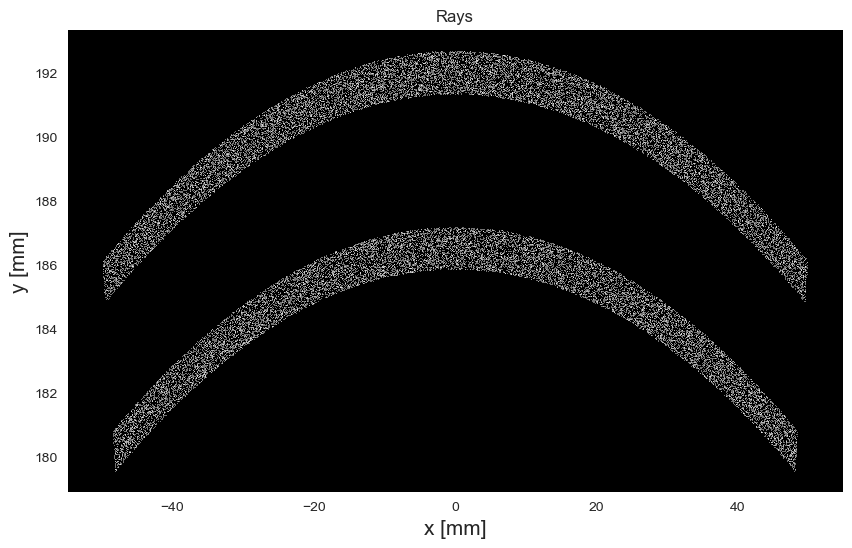

In [19]:
#rays that will hit the optic's shells at all

with sns.axes_style("ticks"):
    
    #matplotlib.rc('text',usetex=True)
    #matplotlib.rc('font',size=15)
    fig1,ax1 = plt.subplots(figsize=(10,6))
    

    ax1.set_xlabel('x [mm]', fontsize=15)
    ax1.set_ylabel('y [mm]', fontsize=15)
    
    ax1.set_facecolor('black')

    ax1.scatter(som1[1], som1[2], color="white", alpha=0.6, marker='.',  s=0.5)
    ax1.scatter(som2[1], som2[2], color="white", alpha=0.6, marker='.',  s=0.5)

    ax1.tick_params(axis='both',which='minor',direction='in')
    ax1.tick_params(top=True,right=True)
    ax1.tick_params(which='minor',top=True,right=True)

    ax1.set_title("Rays")
    #ax1.grid()

In [20]:
print(len(som1[1]) + len(som2[1])) #how many

39291


In [21]:
#Which rays interact with the primary mirror

def loc_primary(rays, r_int):
    
    # Propagate these photons to primary mirror.
    surfaces.wolterprimary(rays, r_int.to('mm').value, z0.to('mm').value)
    
    # Find which photons interact with this mirror.
    ind = np.where((rays[3] > (z0 + mirror_sep/2).to('mm').value) &
                   (rays[3] < (z0 + mirror_sep/2 + mirror_length).to('mm').value))[0]

    # Keep only the photons which interact with the actual size
    # of the mirror
    ind_rays = [r[ind] for r in rays]
    
    return ind_rays

In [22]:
som1 = loc_primary(som1, r_int[0])
som2 = loc_primary(som2, r_int[1])

In [23]:
print(len(som1[1]) + len(som2[1])) #how many

39288


In [24]:
#time to reflect. when you call reflect, there is a surfaces.flat already in it so you will see the 
#transformation when you plot it again

trans.reflect(som1) #reflect rays for mirror 1
trans.reflect(som2) #reflecr rays for mirror 2

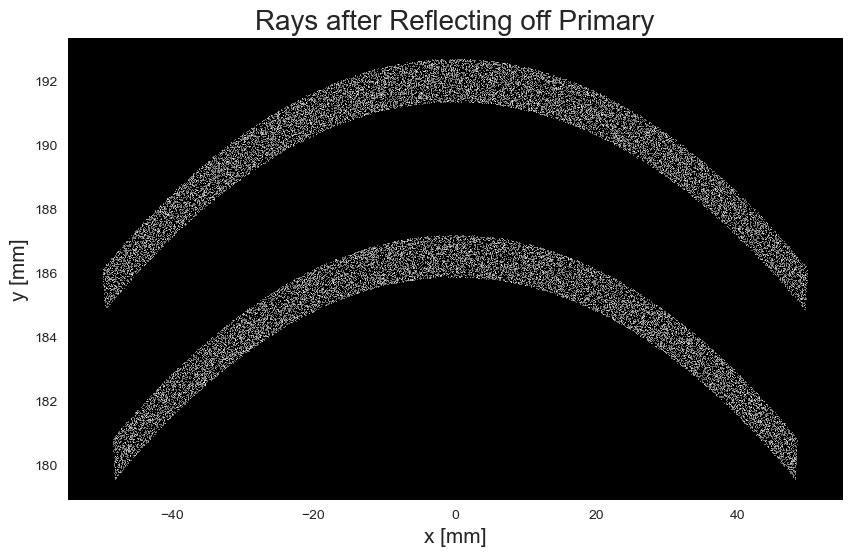

In [25]:
with sns.axes_style("ticks"):
    
    #matplotlib.rc('text',usetex=True)
    #matplotlib.rc('font',size=15)
    fig1,ax1 = plt.subplots(figsize=(10,6))
    

    ax1.set_xlabel('x [mm]', fontsize=15)
    ax1.set_ylabel('y [mm]', fontsize=15)
    
    ax1.set_facecolor('black')

    ax1.scatter(som1[1], som1[2], color="white", alpha=0.6, marker='.',  s=0.5)
    ax1.scatter(som2[1], som2[2], color="white", alpha=0.6, marker='.',  s=0.5)
    

    ax1.tick_params(axis='both',which='minor',direction='in')
    ax1.tick_params(top=True,right=True)
    ax1.tick_params(which='minor',top=True,right=True)

    ax1.set_title("Rays after Reflecting off Primary", fontsize=20)
    #ax1.grid()

In [26]:
#beckman scattering. this is the function i take from ben's oger raytrace 

def beck(num):
    ogre.beckmann_scatter(som1, 0, 0, num)
    ogre.beckmann_scatter(som2, 0, 0, num)
    
    return
    
beck(1.48e-5) #this number is very arbitrary. You vary it until it looks like real life. 
#I actually hate this number
# used to be 1.48e-5

#comment the line above out if you don't want beckman scattering

In [27]:
#time for secondary mirror. Which of the remaining rays interact with the secondary mirror?

def loc_secondary(rays, r_int):
    
    # Propagate photons to the secondary mirror.
    surfaces.woltersecondary(rays, r_int.to('mm').value, z0.to('mm').value)

    # Find which photons will interact with hyperboloid.
    ind = np.where((rays[3] < (z0 - mirror_sep/2).to('mm').value) &
                   (rays[3] > (z0 - mirror_sep/2 - mirror_length).to('mm').value))[0]
    
    # keep only photons which interact with mirror.
    ind_rays = [r[ind] for r in rays]
    
    return ind_rays    

In [28]:
som1 = loc_secondary(som1, r_int[0])
som2 = loc_secondary(som2, r_int[1])

In [29]:
trans.reflect(som1)
trans.reflect(som2)

In [30]:
# add gaussian error

def gauss(num):
    
    som1[5] += np.random.normal(scale=num, size=len(som1[5]))
    som2[5] += np.random.normal(scale=num, size=len(som2[5]))


    som1[6] = -np.sqrt(1. - som1[5]**2 - som1[4]**2)
    som2[6] = -np.sqrt(1. - som2[5]**2 - som2[4]**2)

#gauss(7e-6) # similar to beckmann scatter, this is arbitrary and i hate it
#originally 1.2e-5

#comment the line above out if you don't want beckman scattering

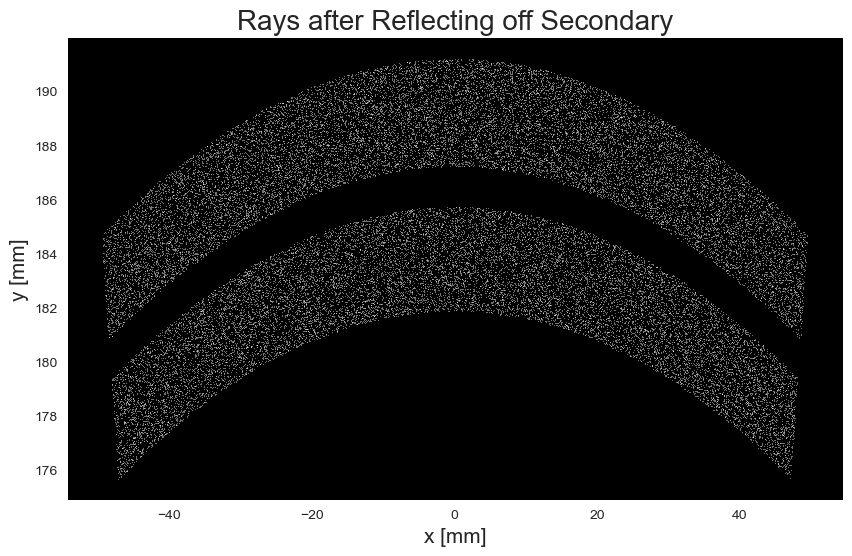

In [31]:
with sns.axes_style("ticks"):
    
    #matplotlib.rc('text',usetex=True)
    #matplotlib.rc('font',size=15)
    fig1,ax1 = plt.subplots(figsize=(10,6))
    

    ax1.set_xlabel('x [mm]', fontsize=15)
    ax1.set_ylabel('y [mm]', fontsize=15)
    
    ax1.set_facecolor('black')

    ax1.scatter(som1[1], som1[2], color="white", alpha=0.6, marker='.',  s=0.5)
    ax1.scatter(som2[1], som2[2], color="white", alpha=0.6, marker='.',  s=0.5)

    ax1.tick_params(axis='both',which='minor',direction='in')
    ax1.tick_params(top=True,right=True)
    ax1.tick_params(which='minor',top=True,right=True)

    ax1.set_title("Rays after Reflecting off Secondary", fontsize=20)
    #ax1.grid()

In [32]:
# Add to 'master' PyXFocus ray object.
new_rays = [np.append(new_rays[i], som1[i])
            for i in range(len(new_rays))]

new_rays = [np.append(new_rays[i], som2[i])
            for i in range(len(new_rays))]

In [33]:
rays = trans.copy_rays(new_rays) #make it so that "rays" is "new_rays"

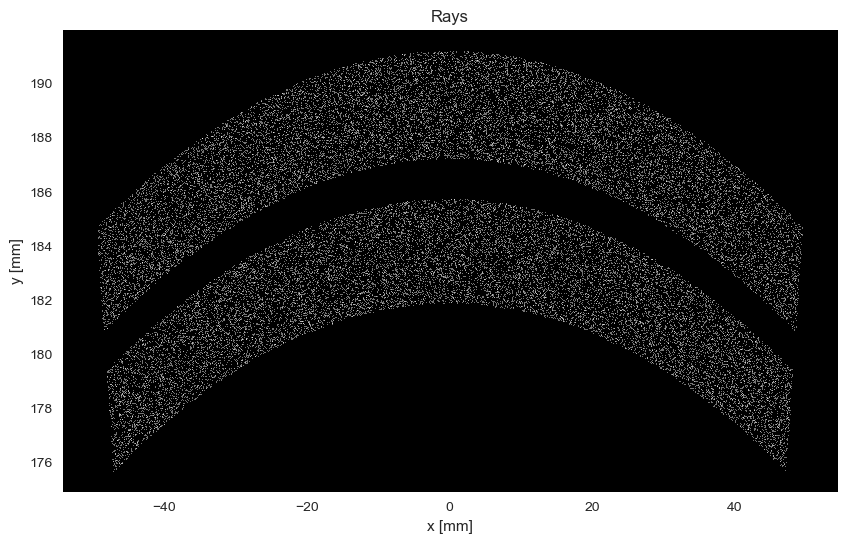

In [34]:
with sns.axes_style("ticks"):
    
    #matplotlib.rc('text',usetex=True)
    #matplotlib.rc('font',size=15)
    fig1,ax1 = plt.subplots(figsize=(10,6))
    

    ax1.set_xlabel('x [mm]')
    ax1.set_ylabel('y [mm]')
    
    ax1.set_facecolor('black')

    ax1.scatter(rays[1], rays[2], color="white", alpha=0.6, marker='.',  s=0.5)

    ax1.tick_params(axis='both',which='minor',direction='in')
    ax1.tick_params(top=True,right=True)
    ax1.tick_params(which='minor',top=True,right=True)

    ax1.set_title("Rays")
    #ax1.grid()

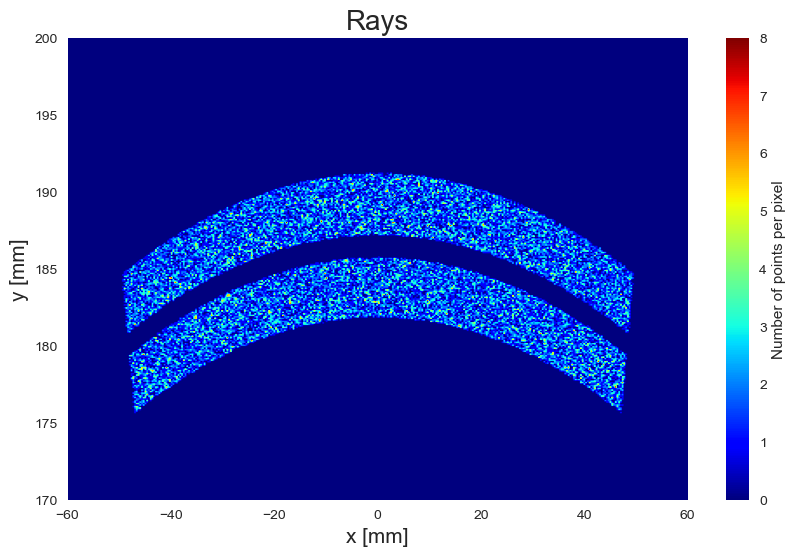

In [35]:
sns.set_style("ticks")
fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(1, 1, 1, projection='scatter_density')

#color_map = plt.get_cmap('plasma')
color_map = plt.get_cmap('jet')

density = ax1.scatter_density(rays[1], rays[2], cmap = color_map)

ax1.set_xlim(-60,60)
ax1.set_ylim(170,200)

ax1.set_xlabel('x [mm]', fontsize=15)
ax1.set_ylabel('y [mm]', fontsize=15)

ax1.set_title("Rays", fontsize=20)

ax1.tick_params(axis='both',which='minor',direction='in')
ax1.tick_params(top=True,right=True)
ax1.tick_params(which='minor',top=True,right=True)

fig.colorbar(density, label='Number of points per pixel')

In [36]:
rays

[array([0., 0., 0., ..., 0., 0., 0.]),
 array([ 8.04620471, 36.15008697, 16.76636108, ..., 41.28167204,
        30.32009589, 35.51921967]),
 array([181.72322633, 180.24038168, 182.42829708, ..., 185.07920578,
        188.53426276, 185.14137955]),
 array([3401.27004183, 3449.63260054, 3433.7595391 , ..., 3459.07517771,
        3491.50175179, 3432.03464408]),
 array([-0.00229728, -0.01018065, -0.00474304, ..., -0.01159356,
        -0.00843791, -0.01005147]),
 array([-0.05334873, -0.05220863, -0.05306271, ..., -0.0534227 ,
        -0.0539005 , -0.05384846]),
 array([-0.9985733 , -0.9985843 , -0.99857992, ..., -0.99850468,
        -0.99851066, -0.99849853]),
 array([-0.04419874, -0.19649369, -0.09144821, ..., -0.21751617,
        -0.15864673, -0.18825462]),
 array([-0.99822683, -0.97969607, -0.99501264, ..., -0.97519597,
        -0.98648584, -0.98126369]),
 array([0.03987055, 0.03982255, 0.03983814, ..., 0.04098209, 0.04095002,
        0.04100935])]

In [37]:
# Go to the X-ray focus.
f0 = surfaces.focusX(rays) #put z to focus; there is a flat in this focus function

print(f0)

#Randy and Casey do not like this function. I typically also do not use it and instead use "transform"
#to move where we are down to where the focal plane is supposed to be. How I typically set up my coordinate 
#systems now, this number should be at z=0
#it should be noted that whenever you "flat," you also reset the orgin of your coordinate system to that position
#so if you print your rays after using "flat," the coordinate altered should all be zeroes

#when you print the focus here, it will say -96 mm. This means that it is -96 mm from where we set up the orgin
# for this coordinate system, which the nominal focal length away from the intersection node (3500 mm). 
#So the focus of these PSOs is 96 mm more than that. This lined up exactly with what we saw at PANTRE (yay)

-96.2278457011621


In [38]:
# Put optic focus at y=0.
cen_y = np.mean(rays[2])
print(cen_y)
trans.transform(rays, 0, cen_y, 0, 0, 0, 0)

# Copy rays to reference later.
of_rays = deepcopy(rays)

rays

-5.145285565036878


[array([0., 0., 0., ..., 0., 0., 0.]),
 array([-1.30226321e-05, -2.51051155e-04, -3.25076148e-04, ...,
         1.31185546e-03,  2.00429254e-03,  1.67215977e-03]),
 array([ 0.01485819, -0.00128734, -0.00348514, ...,  0.00615109,
         0.01068924,  0.00945839]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([-0.00229728, -0.01018065, -0.00474304, ..., -0.01159356,
        -0.00843791, -0.01005147]),
 array([-0.05334873, -0.05220863, -0.05306271, ..., -0.0534227 ,
        -0.0539005 , -0.05384846]),
 array([-0.9985733 , -0.9985843 , -0.99857992, ..., -0.99850468,
        -0.99851066, -0.99849853]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([0., 0., 0., ..., 0., 0., 0.]),
 array([1., 1., 1., ..., 1., 1., 1.])]

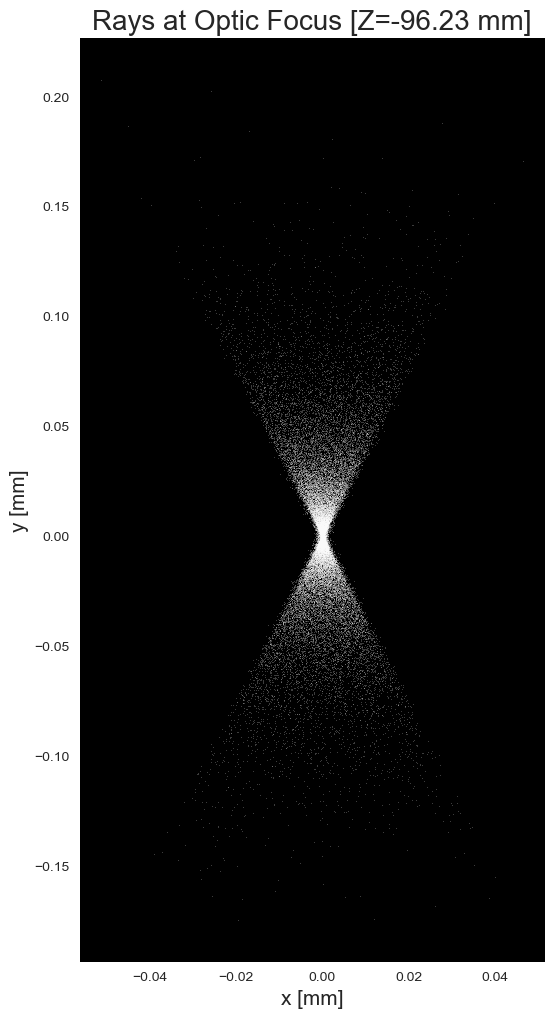

In [40]:
with sns.axes_style("ticks"):
    
    #matplotlib.rc('text',usetex=True)
    #matplotlib.rc('font',size=15)
    fig1,ax1 = plt.subplots(figsize=(6,12))
    

    ax1.set_xlabel('x [mm]', fontsize=15)
    ax1.set_ylabel('y [mm]', fontsize=15)
    
    ax1.set_facecolor('black')

    ax1.scatter(rays[1], rays[2], color="white", alpha=0.3, marker='.',  s=0.5)

    ax1.tick_params(axis='both',which='minor',direction='in')
    ax1.tick_params(top=True,right=True)
    ax1.tick_params(which='minor',top=True,right=True)

    ax1.set_title("Rays at Optic Focus [Z=" + str(round(f0, 2)) + " mm]", fontsize=20)
    #ax1.grid()


the classic bowtie of a subannulus woltor 1

then following this is just a bunch of different ways I visualize PSFs 

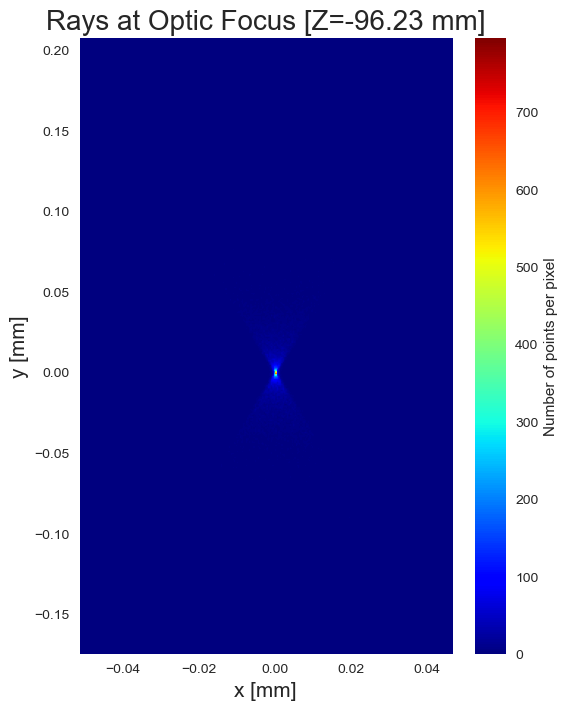

In [41]:
sns.set_style("ticks")
fig = plt.figure(figsize=(6,8))
ax1 = fig.add_subplot(1, 1, 1, projection='scatter_density')

#color_map = plt.get_cmap('plasma')
#color_map = plt.get_cmap('nipy_spectral')
color_map = plt.get_cmap('jet')

density = ax1.scatter_density(rays[1], rays[2], cmap = color_map)
#density = ax1.scatter_density(rays[1], rays[2], cmap = color_map, vmin = 0, vmax = 20)

ax1.set_xlabel('x [mm]', fontsize=15)
ax1.set_ylabel('y [mm]', fontsize=15)

ax1.set_title("Rays at Optic Focus [Z=" + str(round(f0, 2)) + " mm]", fontsize=20)

ax1.tick_params(axis='both',which='minor',direction='in')
ax1.tick_params(top=True,right=True)
ax1.tick_params(which='minor',top=True,right=True)

fig.colorbar(density, label='Number of points per pixel')

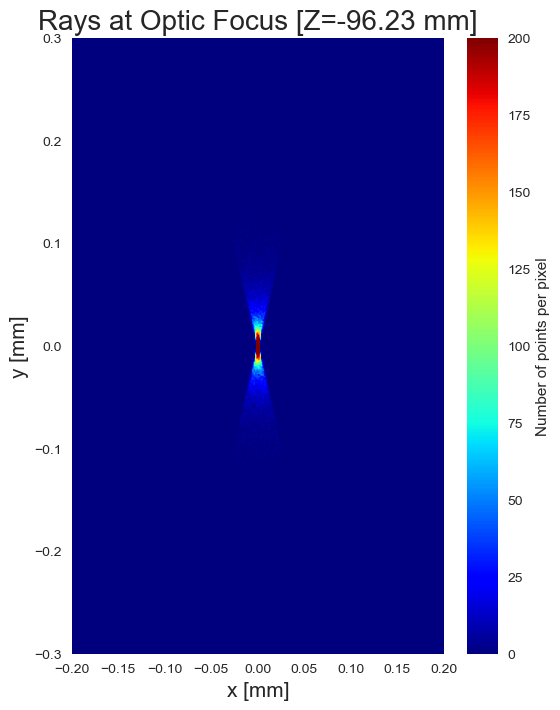

In [42]:
sns.set_style("ticks")
fig = plt.figure(figsize=(6,8))
ax1 = fig.add_subplot(1, 1, 1, projection='scatter_density')

#color_map = plt.get_cmap('plasma')
color_map = plt.get_cmap('jet')

#density = ax1.scatter_density(rays[1], rays[2], cmap = color_map)
density = ax1.scatter_density(rays[1], rays[2], cmap = color_map, vmin = 0, vmax = 200)

ax1.set_ylim(-0.3,0.3)
ax1.set_xlim(-0.2,0.2)

ax1.set_xlabel('x [mm]', fontsize=15)
ax1.set_ylabel('y [mm]', fontsize=15)

ax1.set_title("Rays at Optic Focus [Z=" + str(round(f0, 2)) + " mm]", fontsize=20)

ax1.tick_params(axis='both',which='minor',direction='in')
ax1.tick_params(top=True,right=True)
ax1.tick_params(which='minor',top=True,right=True)

fig.colorbar(density, label='Number of points per pixel')

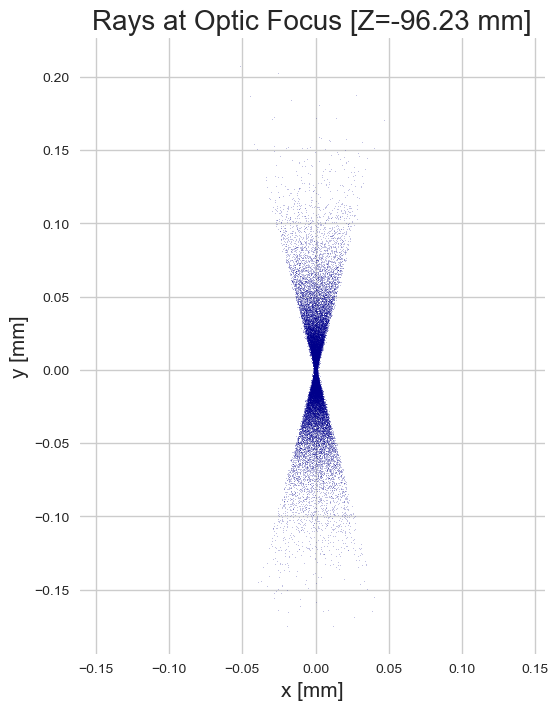

In [43]:
with sns.axes_style("whitegrid"):
    
    #matplotlib.rc('text',usetex=True)
    #matplotlib.rc('font',size=15)
    fig1,ax1 = plt.subplots(figsize=(6,8))

    ax1.set_xlabel('x [mm]', fontsize=15)
    ax1.set_ylabel('y [mm]', fontsize=15)

    ax1.set_title("Rays at Optic Focus [Z=" + str(round(f0, 2)) + " mm]", fontsize=20)

    ax1.scatter(rays[1], rays[2], color="darkblue", alpha=0.3, marker='.',  s=0.5)
    ax1.axis('equal')

    ax1.tick_params(axis='both',which='minor',direction='in')
    ax1.tick_params(top=True,right=True)
    ax1.tick_params(which='minor',top=True,right=True)

    #ax1.grid()